# Converting MLDS Perceptual Scales to MOS values using TID2013

This script loads the database of the MLDS curves described in
**"Response to Affine Transforms of Image Distance Metrics and Humans"**.

Then we select the data that is common with the target database.
In this example we use TID2013, and the common data is the gaussian noise for some particular noise levels. From this selected data we compute the coefficientes of a linear regression.

Then we apply the linear regression to convert all RAID data to MOS.


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install datasets
from datasets import load_dataset

### Load MLDS

In [55]:

url = 'https://raw.githubusercontent.com/paudauo/BBDD_Affine_Transformations/refs/heads/main/perceptual_scales.csv'
df = pd.read_csv(url,header=0, on_bad_lines='skip')
print(df.head(5))

    Reference                Distorted  Curve_Value    Sigmas  Percept_scale  \
0  img_01.png  rot_img_01_level_01.png     0.000000  0.220711       0.000000   
1  img_01.png  rot_img_01_level_02.png     0.113924  0.220711       0.516166   
2  img_01.png  rot_img_01_level_03.png     0.185471  0.220711       0.840336   
3  img_01.png  rot_img_01_level_04.png     0.346350  0.220711       1.569247   
4  img_01.png  rot_img_01_level_05.png     0.417098  0.220711       1.889793   

   Estimated_MOS  
0       5.435624  
1       5.167124  
2       4.998498  
3       4.619332  
4       4.452589  


In [56]:
#Choose only images that are common in both databases
filter = df['Distorted'].str.contains(r'^gn_.*_level_(02|03|05|10)\.png$', regex=True)
df_filtered = df[filter]

MLDS_filtered = df_filtered.Percept_scale.to_numpy()

/tmp/ipython-input-3559127169.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filter = df['Distorted'].str.contains(r'^gn_.*_level_(02|03|05|10)\.png$', regex=True)


### Load MOS of TID2013

In [57]:
url = "https://raw.githubusercontent.com/paudauo/MOS_MSE_TID_2013/main/MSE_TID2013.csv"
df2 = pd.read_csv(url)
print(df2.head())

mos = df2["MOS"].values  # Convertir a array de NumPy
group_size = 120
mos_gn = []
for i in range(0, len(mos), group_size):
    mos_gn.append(mos[i:i+5])

mos_gn = np.concatenate(mos_gn)
mos_gn = mos_gn[:-5]

ind = list(range(0, 120, 5))
mos_filtered = np.delete(mos_gn, ind, axis=0)


   Unnamed: 0 Reference     Distorted      MOS  Reference_ID  Distortion_ID  \
0           0   I01.BMP  i01_01_1.bmp  5.51429             1              1   
1           1   I01.BMP  i01_01_2.bmp  5.56757             1              1   
2           2   I01.BMP  i01_01_3.bmp  4.94444             1              1   
3           3   I01.BMP  i01_01_4.bmp  4.37838             1              1   
4           4   I01.BMP  i01_01_5.bmp  3.86486             1              1   

   Distortion_Intensity  Distance  
0                     1  0.000493  
1                     2  0.000983  
2                     3  0.001996  
3                     4  0.003966  
4                     5  0.007915  


### Compute regression cofficients

In [58]:
# Mean, standard deviation and cross-covariance
mu_TID = np.mean(mos_filtered)

mu_MLDS= np.mean(MLDS_filtered)
sigma_MLDS = np.std(MLDS_filtered)

cov_TID_MLDS = np.cov(mos_filtered,MLDS_filtered)[0,1]

#Coefficients
a = cov_TID_MLDS / sigma_MLDS**2
b = mu_TID - a * mu_MLDS
print(a)
print(b)

-0.5201812690454135
5.435624440703925


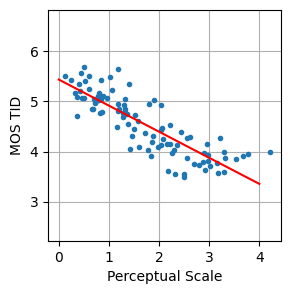

In [59]:
xx = np.linspace(0,4,100)
yy = a * xx + b

plt.figure(figsize = (3,3))
plt.plot(MLDS_filtered,mos_filtered,'.')
plt.plot(xx,yy,'r')
plt.ylabel('MOS TID')
plt.xlabel('Perceptual Scale')
plt.axis('equal')
plt.grid()



Text(0.5, 1.0, 'Correlation: 0.84')

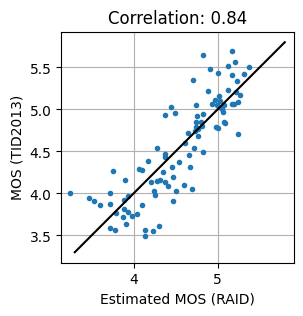

In [60]:
# Transforming all the RAID MLDS values using the fitted Transformation
est_MOS_filtered = a * MLDS_filtered + b

#
plt.figure(figsize = (3,3))
plt.plot(est_MOS_filtered,mos_filtered,'.')
plt.plot([3.3,5.8],[3.3,5.8],'k')
plt.ylabel('MOS (TID2013)')
plt.xlabel('Estimated MOS (RAID)')
plt.axis('equal')
plt.grid()

plt.title('Correlation: ' + str(np.round(np.corrcoef(est_MOS_filtered,mos_filtered)[0,1],2)))



### Transform all the RAID data

In [61]:
# Transforming all the MLDS values using the fitted Transformation
est_MOS = a * df.Percept_scale + b


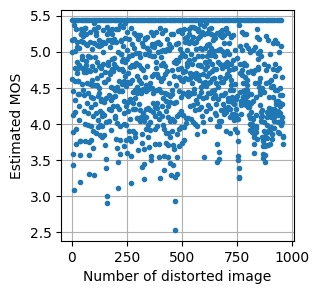

In [62]:
plt.figure(figsize = (3,3))
plt.plot(est_MOS,'.')
plt.xlabel('Number of distorted image')
plt.ylabel('Estimated MOS')
plt.grid()